# IEM creativity tilt

The tilted density re-weights the prior: $q_\lambda(x) \propto p(x) \cdot \exp(\lambda \cdot \mathbb{E}_{x' \sim p}[D(x', x)])$, concentrating mass on points that are far (in the IEM sense) from the observed distribution — revealing the creative gap left by the missing mode.

In [2]:
import sys, math, torch, matplotlib.pyplot as plt
sys.path.insert(0, '.')
from creativity_measure import *
dtype = torch.float64
torch.set_default_dtype(dtype)

## Ring GMM with a hole

In [ ]:
# Ring GMM with hole — pure tensor ops (vmap-safe, no torch.distributions)
D, N_TOTAL, HOLE_IDX, RADIUS, SIGMA = 2, 12, 0, 4.0, 0.3
angles = 2 * math.pi * torch.arange(N_TOTAL, dtype=dtype) / N_TOTAL
all_means = torch.stack([RADIUS * torch.cos(angles), RADIUS * torch.sin(angles)], dim=-1)
mask = torch.ones(N_TOTAL, dtype=torch.bool)
mask[HOLE_IDX] = False
MEANS = all_means[mask]          # (K, 2) observed modes (hole removed)
K = MEANS.shape[0]
S2 = SIGMA ** 2
logK = math.log(K)

def log_pX(x):
    # Equal-weight isotropic GMM, pure tensor ops (vmap-safe)
    diff = x.unsqueeze(-2) - MEANS          # (..., K, 2)
    quad = diff.pow(2).sum(-1) / S2         # (..., K)
    logcomp = -0.5 * quad -0.5 * D * math.log(2 * math.pi * S2)
    return torch.logsumexp(logcomp, dim=-1) - logK

def log_pY(y, gamma):
    # Y = gamma*X + sqrt(gamma)*W; comp k ~ N(gamma*mu_k, (gamma^2*S2 + gamma)*I)
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var = gamma ** 2 * S2 + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS  # (..., K, 2)
    quad = diff.pow(2).sum(-1) / var
    logcomp = -0.5 * quad -0.5 * D * torch.log(2 * math.pi * var)
    return torch.logsumexp(logcomp, dim=-1) - logK

def ring_sample(n):
    comp = torch.randint(K, (n,))
    return MEANS[comp] + SIGMA * torch.randn(n, 2, dtype=dtype)

p_ring = Density(log_pX, log_pY, sample_fn=ring_sample, d=2)
print(f"Ring GMM: {K} observed modes (hole at index {HOLE_IDX}), radius={RADIUS}, sigma={SIGMA}")

# Grid and reference points
grid_points_ring, XX, YY, cell_area = make_grid((-6, 6), (-6, 6), grid_n=50, dtype=dtype)
log_p_grid_ring = p_ring.log_p_X(grid_points_ring)
x_refs = p_ring.sample(32, seed=123)
print(f"Grid: {grid_points_ring.shape[0]} points, cell_area={cell_area:.4f}; x_refs shape: {x_refs.shape}")

### Ring GMM with a hole - Local IEM

In [ ]:
GAMMAS_LOCAL = torch.logspace(-4, 4, 128, base=2, dtype=dtype)
D_local_ring = LocalIEMDistance(p_ring, GAMMAS_LOCAL, num_noises=50)
expected_dist_ring = expected_distance(D_local_ring, grid_points_ring, x_refs)

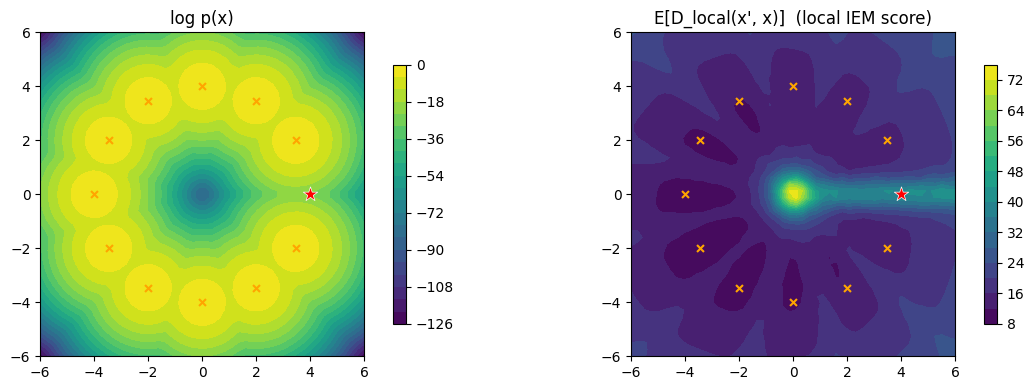

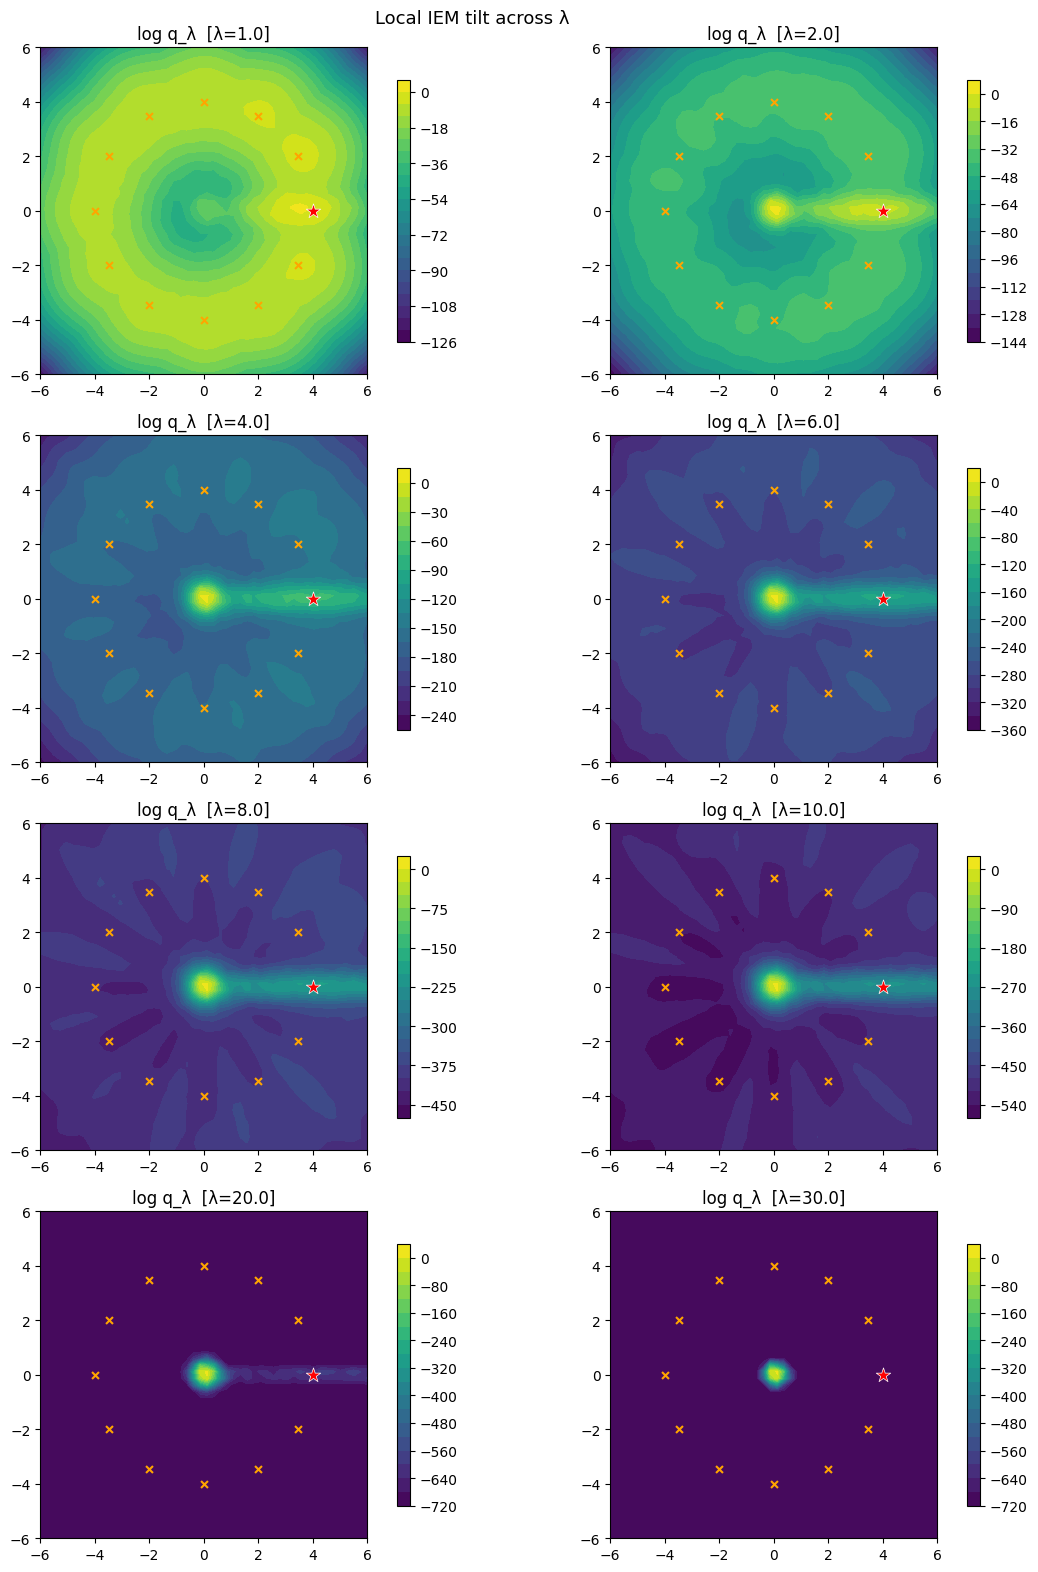

In [25]:
# plot log p and local IEM score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_field(log_p_grid_ring, XX, YY, ax=axes[0], title="log p(x)",
           marked=MEANS, missing=all_means[~mask])
plot_field(expected_dist_ring, XX, YY, ax=axes[1], title="E[D_local(x', x)]  (local IEM score)",
           marked=MEANS, missing=all_means[~mask])
plt.tight_layout(); plt.show()

# Plot local IEM creativity measure for different λ values
lambdas = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 20.0, 30.0]

ncols = 2
nrows = math.ceil(len(lambdas) / ncols)
PANEL_W, PANEL_H = 6, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(PANEL_W * ncols, PANEL_H * nrows))
axes = axes.flatten()
for i, LAMBDA in enumerate(lambdas):
    log_q_unnorm = log_p_grid_ring + LAMBDA * expected_dist_ring
    log_q, q, Z = grid_normalize(log_q_unnorm, cell_area)
    plot_field(log_q, XX, YY, ax=axes[i], title=f"log q_λ  [λ={LAMBDA}]",
               marked=MEANS, missing=all_means[~mask])
fig.suptitle("Local IEM tilt across λ", fontsize=13)
plt.tight_layout()
plt.show()

### Ring GMM with a hole - Global IEM

In [27]:
GAMMAS_GLOBAL = torch.logspace(-10, 10, 200, base=2, dtype=dtype)
D_global_ring = GlobalIEMDistance(p_ring, GAMMAS_GLOBAL, num_eps=16)
expected_dist_global_ring = expected_distance(D_global_ring, grid_points_ring, x_refs)

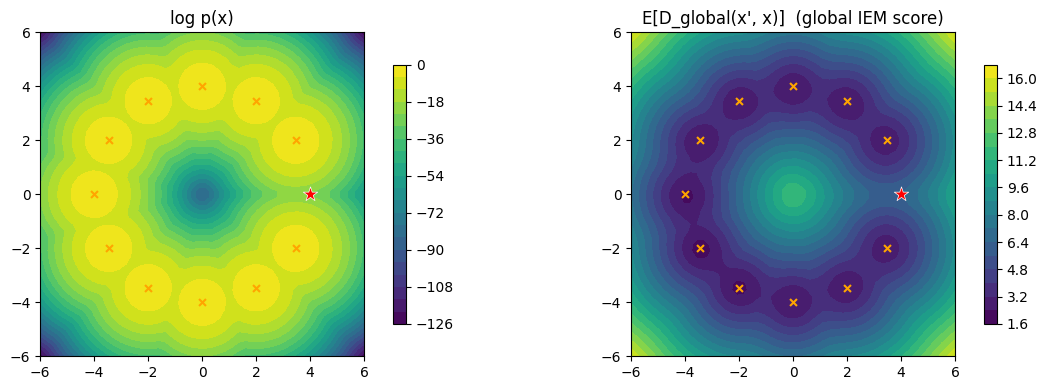

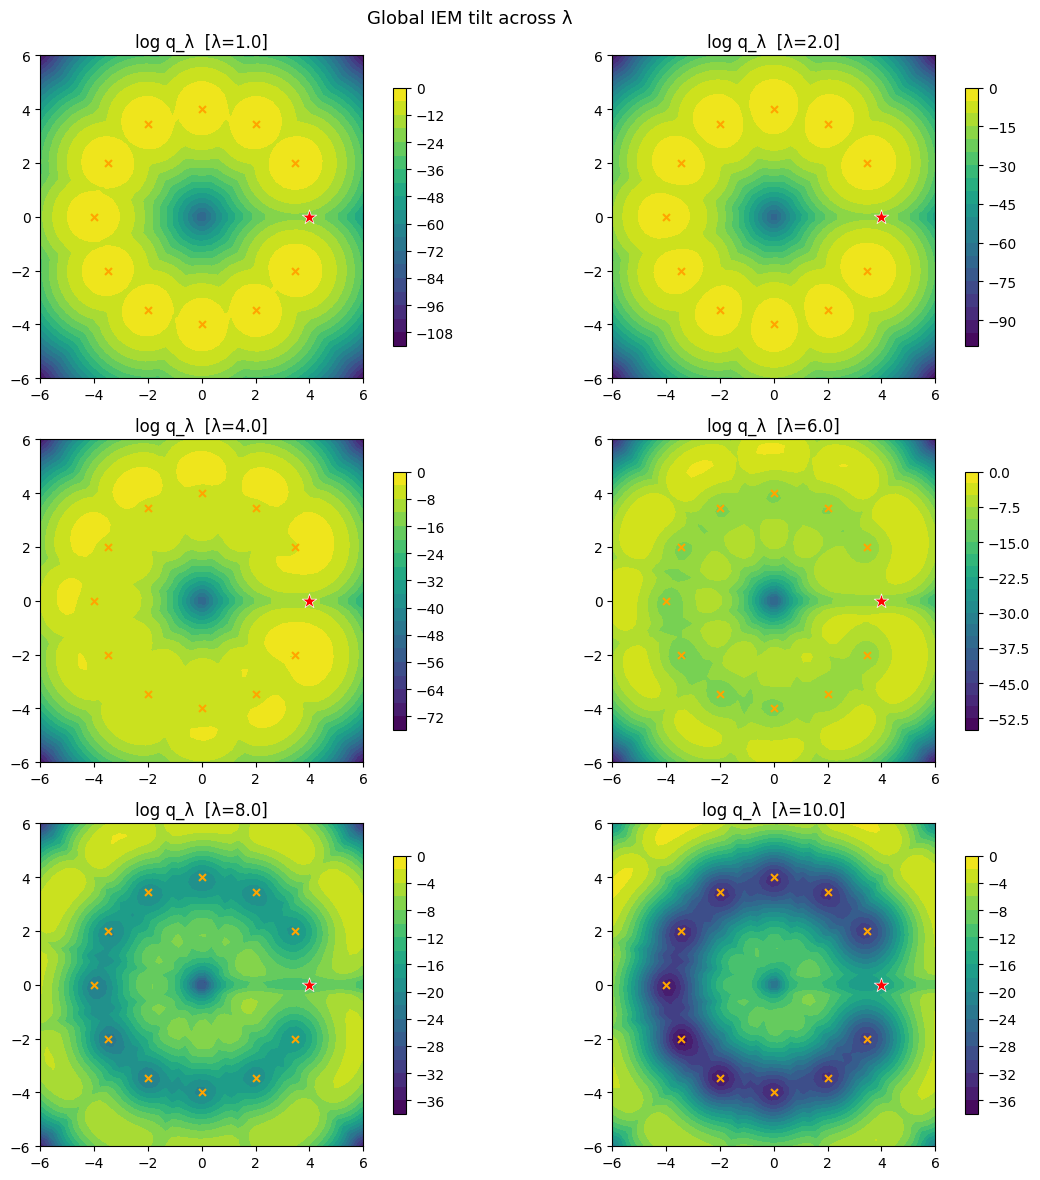

In [29]:
# plot log p and global IEM score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_field(log_p_grid_ring, XX, YY, ax=axes[0], title="log p(x)",
           marked=MEANS, missing=all_means[~mask])
plot_field(expected_dist_global_ring, XX, YY, ax=axes[1],
           title="E[D_global(x', x)]  (global IEM score)",
           marked=MEANS, missing=all_means[~mask])
plt.tight_layout(); plt.show()

# Plot global IEM creativity measure for different λ values
lambdas = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0]

ncols = 2
nrows = math.ceil(len(lambdas) / ncols)
PANEL_W, PANEL_H = 6, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(PANEL_W * ncols, PANEL_H * nrows))
axes = axes.flatten()
for i, LAMBDA in enumerate(lambdas):
    log_q_unnorm = log_p_grid_ring + LAMBDA * expected_dist_global_ring
    log_q, q, Z = grid_normalize(log_q_unnorm, cell_area)
    plot_field(log_q, XX, YY, ax=axes[i], title=f"log q_λ  [λ={LAMBDA}]",
               marked=MEANS, missing=all_means[~mask])
fig.suptitle("Global IEM tilt across λ", fontsize=13)
plt.tight_layout()
plt.show()

# Two Moons

In [ ]:
K_PER_MOON = 16         # Gaussians per arc
SIGMA = 0.18            # component width (keep ≈ bead spacing: RADIUS*ARC/(K-1))
S2 = SIGMA ** 2
ARC = 0.5 * math.pi     # angular span of each arc: π = closed C-shape, smaller = more open/flatter
RADIUS = 3              # arc size; larger = longer arcs
H_SHIFT = 2             # horizontal offset of moon2 (0 = directly below moon1)
V_SHIFT = 0.0           # vertical distance between the two moons

t = (math.pi - ARC) / 2 + ARC * torch.arange(K_PER_MOON, dtype=dtype) / (K_PER_MOON - 1)
moon1 = torch.stack([RADIUS * torch.cos(t), RADIUS * torch.sin(t)], dim=-1)
moon2 = torch.stack([RADIUS * torch.cos(t) + H_SHIFT, -RADIUS * torch.sin(t) - V_SHIFT], dim=-1)
MEANS = torch.cat([moon1, moon2], dim=0)
K = MEANS.shape[0]
logK = math.log(K)
Dd = MEANS.shape[1]

def log_pX(x):
    diff = x.unsqueeze(-2) - MEANS
    quad = diff.pow(2).sum(-1) / S2
    logcomp = -0.5 * quad - 0.5 * Dd * math.log(2 * math.pi * S2)
    return torch.logsumexp(logcomp, dim=-1) - logK

def log_pY(y, gamma):
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var = gamma ** 2 * S2 + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS
    quad = diff.pow(2).sum(-1) / var
    logcomp = -0.5 * quad - 0.5 * Dd * torch.log(2 * math.pi * var)
    return torch.logsumexp(logcomp, dim=-1) - logK

def moons_sample(n):
    comp = torch.randint(K, (n,))
    return MEANS[comp] + SIGMA * torch.randn(n, 2, dtype=dtype)

p_moons = Density(log_pX, log_pY, sample_fn=moons_sample, d=2)
print(f"Two-moons GMM: {K} components ({K_PER_MOON}/moon), sigma={SIGMA}")

# Grid and reference points
grid_points_moons, XX, YY, cell_area = make_grid((-8, 9), (-8, 7), grid_n=50, dtype=dtype)
log_p_grid_moons = p_moons.log_p_X(grid_points_moons)
x_refs = p_moons.sample(32, seed=123)
print(f"Grid: {grid_points_moons.shape[0]} points, cell_area={cell_area:.4f}; refs: {x_refs.shape}")

### Two Moons - Local IEM

In [17]:
GAMMAS_LOCAL = torch.logspace(-4, 4, 128, base=2, dtype=dtype)
D_local_moons = LocalIEMDistance(p_moons, GAMMAS_LOCAL, num_noises=50)
expected_dist_moons = expected_distance(D_local_moons, grid_points_moons, x_refs)

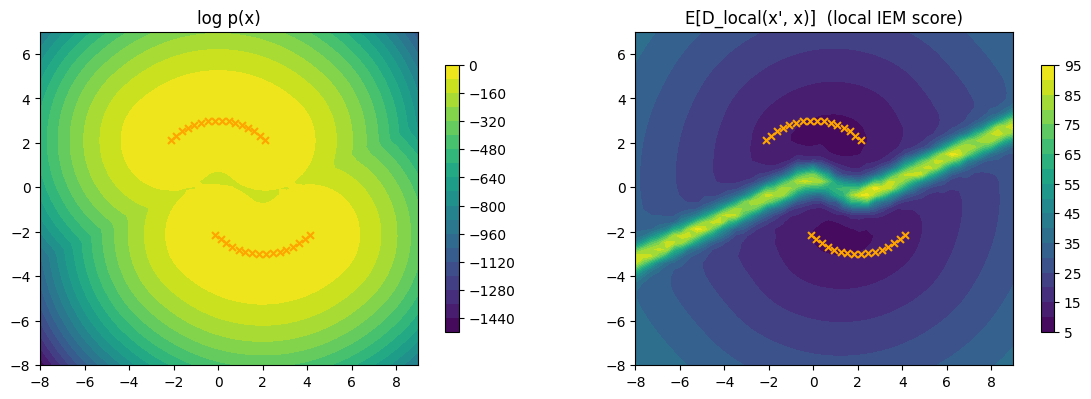

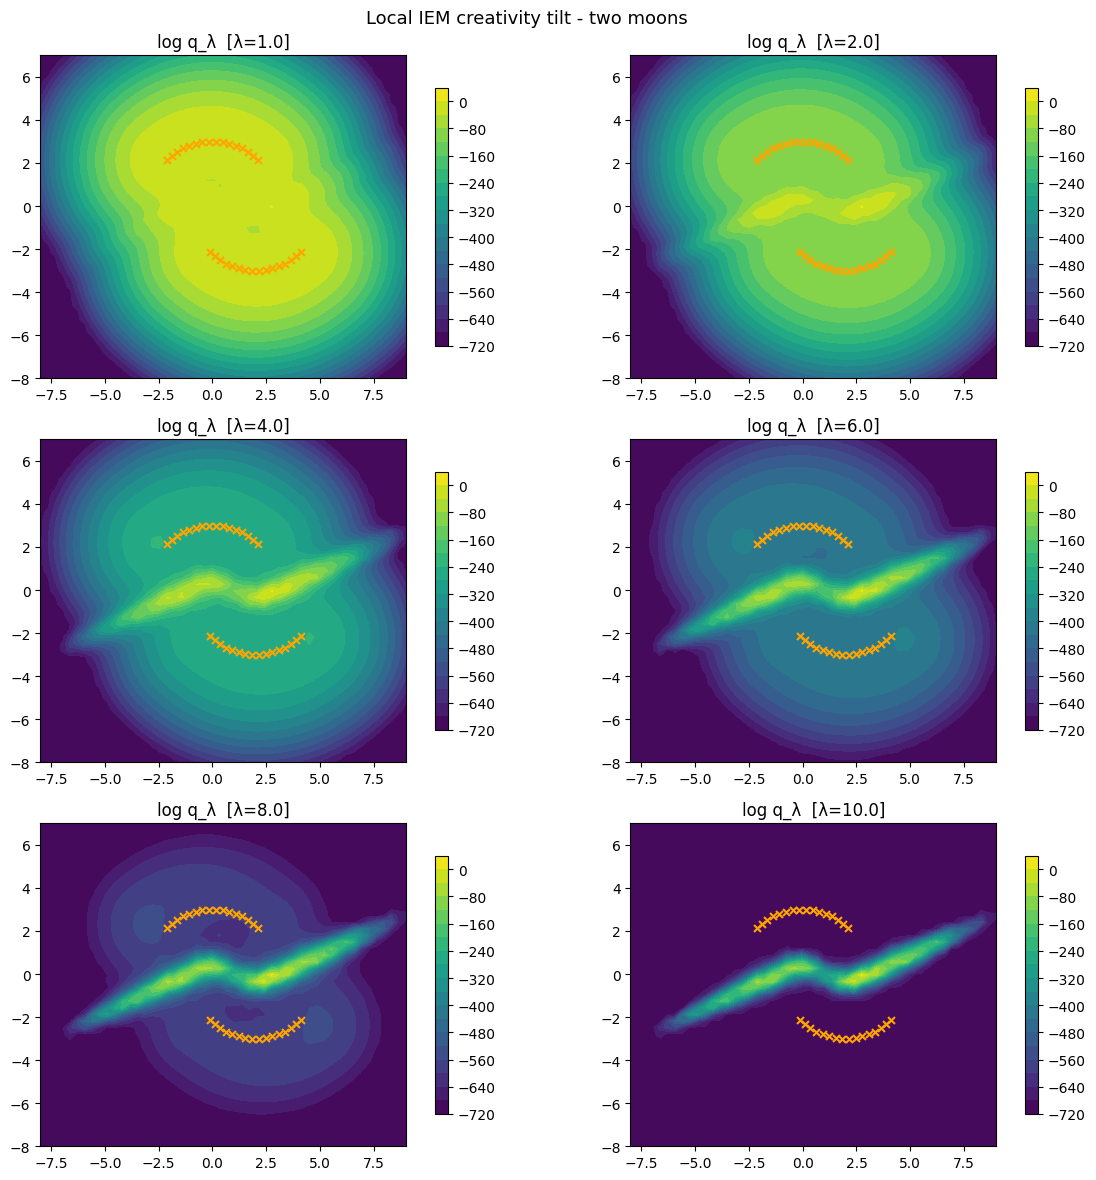

In [18]:
# plot log p and local IEM score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_field(log_p_grid_moons, XX, YY, ax=axes[0], title="log p(x)", marked=MEANS)
plot_field(expected_dist_moons, XX, YY, ax=axes[1],
           title="E[D_local(x', x)]  (local IEM score)", marked=MEANS)
plt.tight_layout(); plt.show()

# Plot local IEM creativity measure for different λ values
lambdas = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0]

ncols = 2
nrows = math.ceil(len(lambdas) / ncols)
PANEL_W, PANEL_H = 6, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(PANEL_W * ncols, PANEL_H * nrows))
axes = axes.flatten()
for i, LAMBDA in enumerate(lambdas):
    log_q_unnorm = log_p_grid_moons + LAMBDA * expected_dist_moons
    log_q, q, Z = grid_normalize(log_q_unnorm, cell_area)
    plot_field(log_q, XX, YY, ax=axes[i], title=f"log q_λ  [λ={LAMBDA}]", marked=MEANS)
for j in range(len(lambdas), len(axes)):
    axes[j].axis('off')
fig.suptitle("Local IEM creativity tilt - two moons", fontsize=13)
plt.tight_layout(); plt.show()

### Two Moons - Global IEM

In [21]:
GAMMAS_GLOBAL = torch.logspace(-10, 10, 200, base=2, dtype=dtype)
D_global_moons = GlobalIEMDistance(p_moons, GAMMAS_GLOBAL, num_eps=16)
expected_dist_global_moons = expected_distance(D_global_moons, grid_points_moons, x_refs)

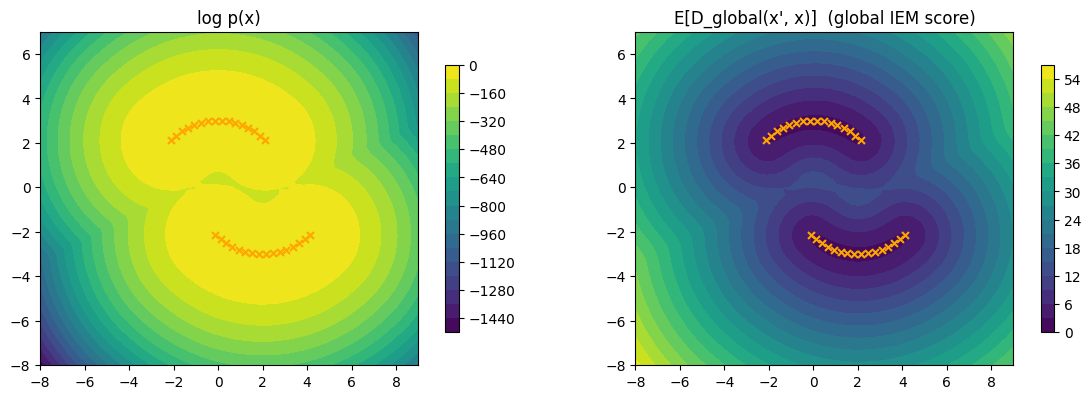

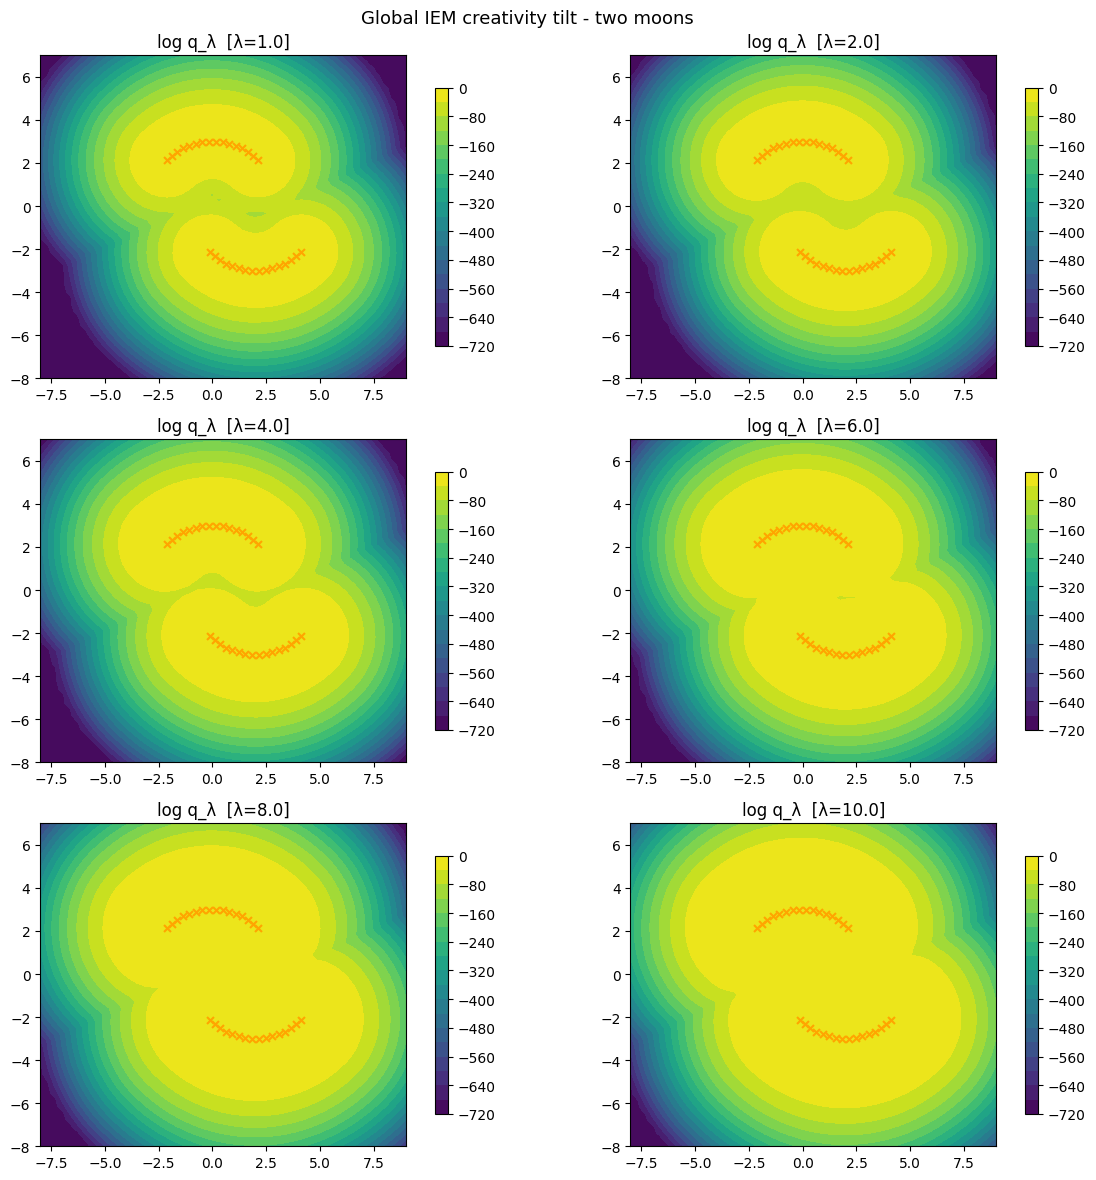

In [22]:
# plot log p and global IEM score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_field(log_p_grid_moons, XX, YY, ax=axes[0], title="log p(x)", marked=MEANS)
plot_field(expected_dist_global_moons, XX, YY, ax=axes[1],
           title="E[D_global(x', x)]  (global IEM score)", marked=MEANS)
plt.tight_layout(); plt.show()

# Plot global IEM creativity measure for different λ values
lambdas = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0]

ncols = 2
nrows = math.ceil(len(lambdas) / ncols)
PANEL_W, PANEL_H = 6, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(PANEL_W * ncols, PANEL_H * nrows))
axes = axes.flatten()
for i, LAMBDA in enumerate(lambdas):
    log_q_unnorm = log_p_grid_moons + LAMBDA * expected_dist_global_moons
    log_q, q, Z = grid_normalize(log_q_unnorm, cell_area)
    plot_field(log_q, XX, YY, ax=axes[i], title=f"log q_λ  [λ={LAMBDA}]", marked=MEANS)
for j in range(len(lambdas), len(axes)):
    axes[j].axis('off')
fig.suptitle("Global IEM creativity tilt - two moons", fontsize=13)
plt.tight_layout(); plt.show()

## Two moons with a hole

In [ ]:
K_PER_MOON = 16                 # Gaussians per arc
SIGMA = 0.18                    # component width (keep ≈ bead spacing: RADIUS*ARC/(K-1))
S2 = SIGMA ** 2
ARC = 0.5 * math.pi             # angular span of each arc: π = closed C-shape, smaller = more open/flatter
RADIUS = 3                      # arc size; larger = longer arcs
H_SHIFT = 2                     # horizontal offset of moon2 (0 = directly below moon1)
V_SHIFT = 0.0                   # vertical distance between the two moons

HOLE_MOON = 1                   # 0 = upper moon, 1 = lower moon
HOLE_START, HOLE_END = 2, 11     # remove beads [HOLE_START, HOLE_END) from that arc

t = (math.pi - ARC) / 2 + ARC * torch.arange(K_PER_MOON, dtype=dtype) / (K_PER_MOON - 1)
moon1 = torch.stack([RADIUS * torch.cos(t), RADIUS * torch.sin(t)], dim=-1)
moon2 = torch.stack([RADIUS * torch.cos(t) + H_SHIFT, -RADIUS * torch.sin(t) - V_SHIFT], dim=-1)
all_means = torch.cat([moon1, moon2], dim=0)        # full set, before removal

# Build a mask that removes a contiguous slice of one arc
mask = torch.ones(all_means.shape[0], dtype=torch.bool)
offset = HOLE_MOON * K_PER_MOON                      # 0 for moon1, K_PER_MOON for moon2
mask[offset + HOLE_START : offset + HOLE_END] = False

MEANS = all_means[mask]          # kept components (used in the density)
MISSING = all_means[~mask]       # removed components (the hole) — for plotting
K = MEANS.shape[0]
logK = math.log(K)
Dd = MEANS.shape[1]

def log_pX(x):
    diff = x.unsqueeze(-2) - MEANS
    quad = diff.pow(2).sum(-1) / S2
    logcomp = -0.5 * quad - 0.5 * Dd * math.log(2 * math.pi * S2)
    return torch.logsumexp(logcomp, dim=-1) - logK

def log_pY(y, gamma):
    gamma = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var = gamma ** 2 * S2 + gamma
    diff = y.unsqueeze(-2) - gamma * MEANS
    quad = diff.pow(2).sum(-1) / var
    logcomp = -0.5 * quad - 0.5 * Dd * torch.log(2 * math.pi * var)
    return torch.logsumexp(logcomp, dim=-1) - logK

def moons_sample(n):
    comp = torch.randint(K, (n,))
    return MEANS[comp] + SIGMA * torch.randn(n, 2, dtype=dtype)

p_moons2 = Density(log_pX, log_pY, sample_fn=moons_sample, d=2)
print(f"Two-moons GMM (hole): {K} kept components, "
      f"removed beads [{HOLE_START},{HOLE_END}) of moon {HOLE_MOON}, sigma={SIGMA}")

# Grid and reference points
grid_points_moons2, XX, YY, cell_area = make_grid((-8, 9), (-8, 7), grid_n=50, dtype=dtype)
log_p_grid_moons2 = p_moons2.log_p_X(grid_points_moons2)
x_refs = p_moons2.sample(32, seed=123)
print(f"Grid: {grid_points_moons2.shape[0]} points, cell_area={cell_area:.4f}; refs: {x_refs.shape}")

### Two Moons with a hole - Local IEM

In [13]:
GAMMAS_LOCAL = torch.logspace(-4, 4, 128, base=2, dtype=dtype)
D_local_moons2 = LocalIEMDistance(p_moons2, GAMMAS_LOCAL, num_noises=50)
expected_dist_moons2 = expected_distance(D_local_moons2, grid_points_moons2, x_refs)

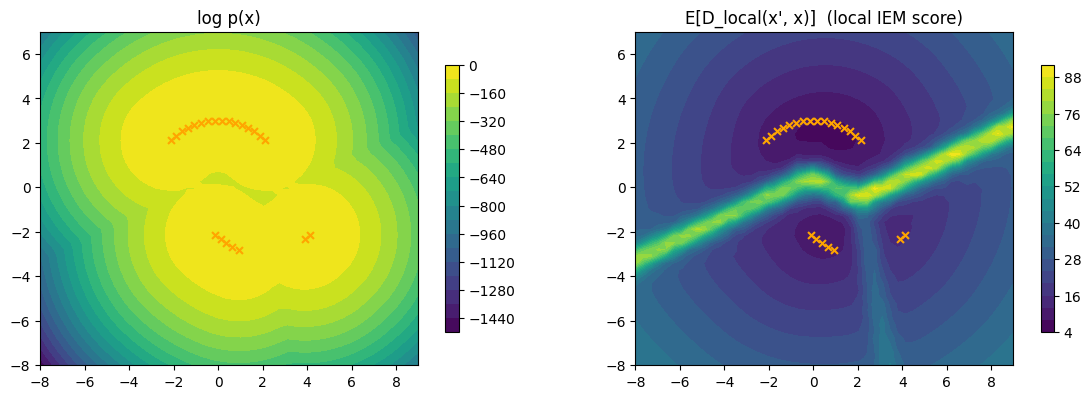

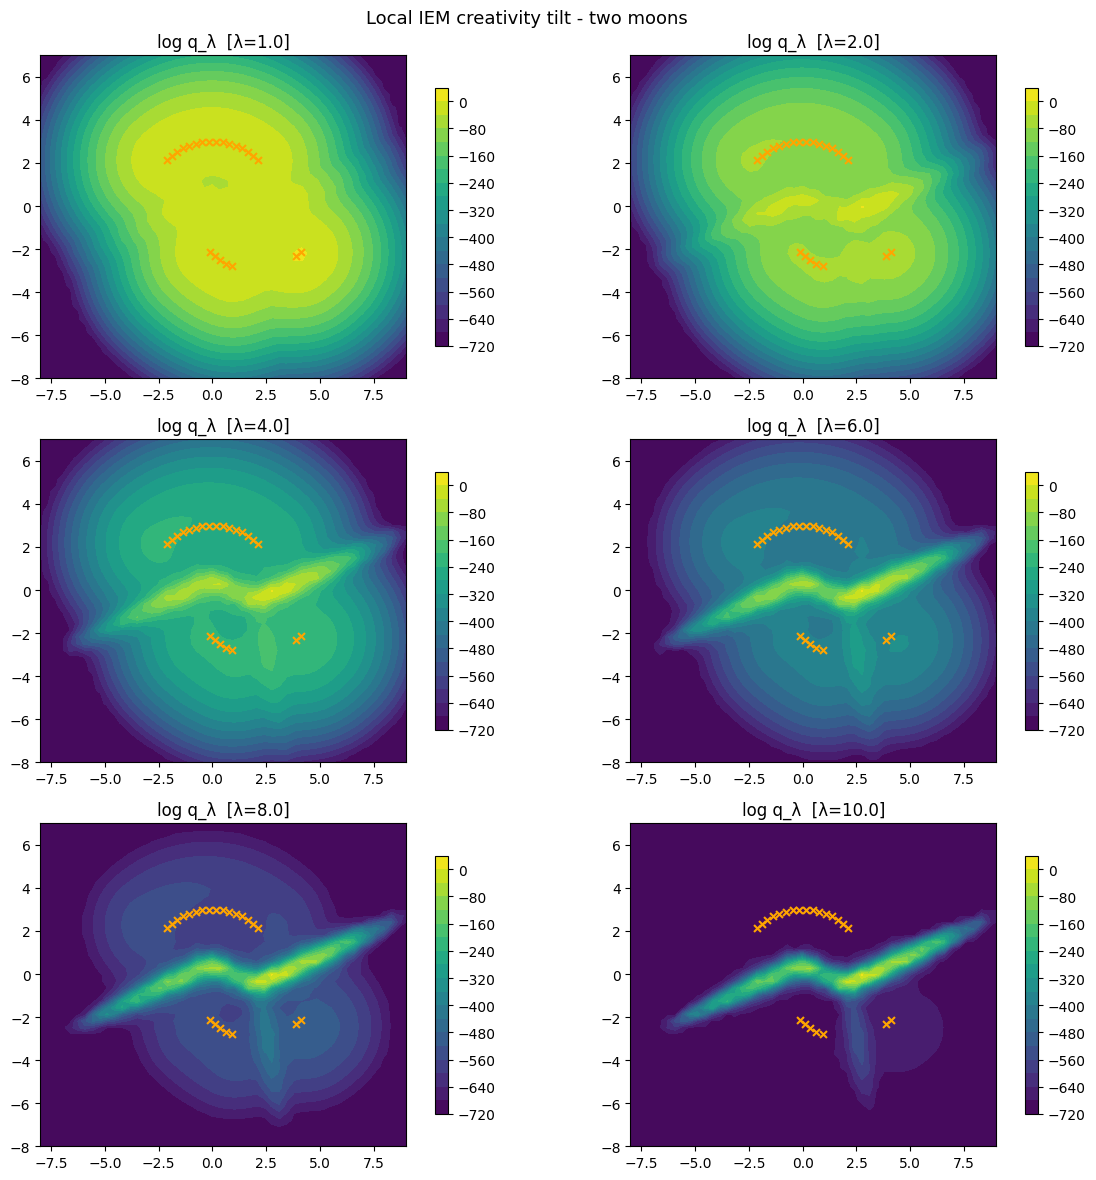

In [14]:
# plot log p and local IEM score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_field(log_p_grid_moons2, XX, YY, ax=axes[0], title="log p(x)", marked=MEANS)
plot_field(expected_dist_moons2, XX, YY, ax=axes[1],
           title="E[D_local(x', x)]  (local IEM score)", marked=MEANS)
plt.tight_layout(); plt.show()

# Plot local IEM creativity measure for different λ values
lambdas = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0]

ncols = 2
nrows = math.ceil(len(lambdas) / ncols)
PANEL_W, PANEL_H = 6, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(PANEL_W * ncols, PANEL_H * nrows))
axes = axes.flatten()
for i, LAMBDA in enumerate(lambdas):
    log_q_unnorm = log_p_grid_moons2 + LAMBDA * expected_dist_moons2
    log_q, q, Z = grid_normalize(log_q_unnorm, cell_area)
    plot_field(log_q, XX, YY, ax=axes[i], title=f"log q_λ  [λ={LAMBDA}]", marked=MEANS)
for j in range(len(lambdas), len(axes)):
    axes[j].axis('off')
fig.suptitle("Local IEM creativity tilt - two moons", fontsize=13)
plt.tight_layout(); plt.show()

### Two Moons with a hole - Global IEM

In [24]:
GAMMAS_GLOBAL = torch.logspace(-10, 10, 200, base=2, dtype=dtype)
D_global_moons2 = GlobalIEMDistance(p_moons2, GAMMAS_GLOBAL, num_eps=16)
expected_dist_global_moons2 = expected_distance(D_global_moons2, grid_points_moons2, x_refs)

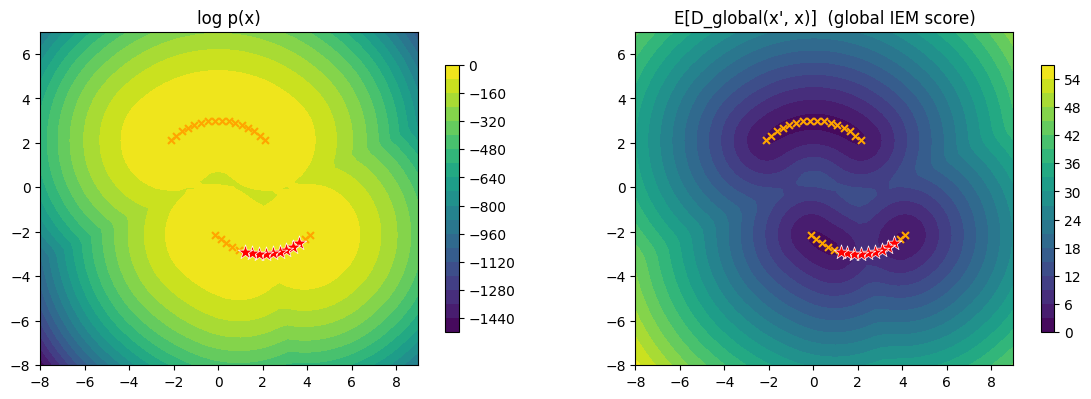

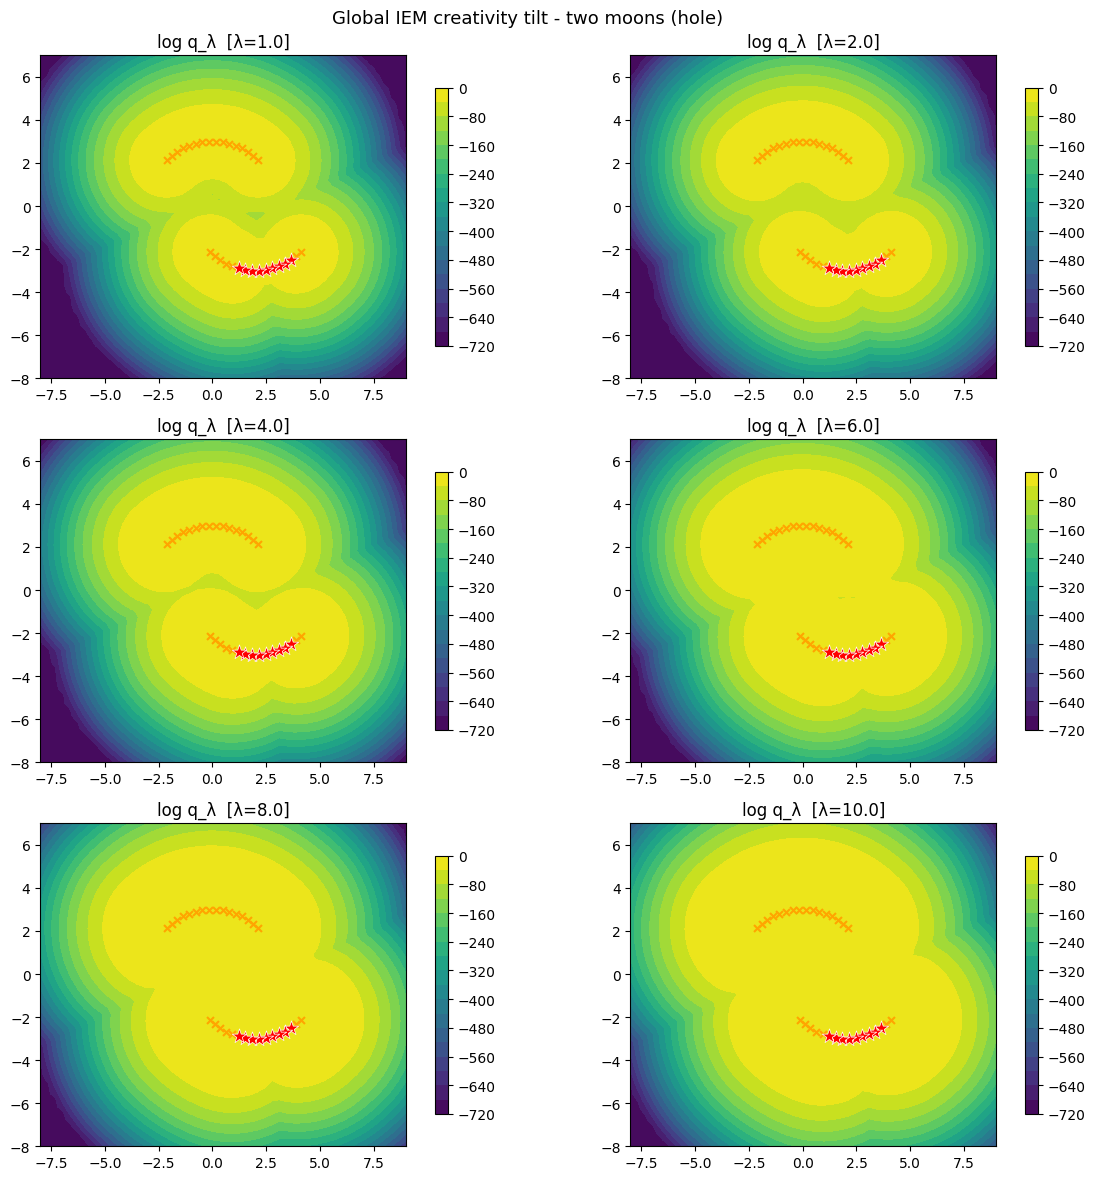

In [25]:
# plot log p and global IEM score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_field(log_p_grid_moons2, XX, YY, ax=axes[0], title="log p(x)",
           marked=MEANS, missing=MISSING)
plot_field(expected_dist_global_moons2, XX, YY, ax=axes[1],
           title="E[D_global(x', x)]  (global IEM score)",
           marked=MEANS, missing=MISSING)
plt.tight_layout(); plt.show()

# Plot global IEM creativity measure for different λ values
lambdas = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0]

ncols = 2
nrows = math.ceil(len(lambdas) / ncols)
PANEL_W, PANEL_H = 6, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(PANEL_W * ncols, PANEL_H * nrows))
axes = axes.flatten()
for i, LAMBDA in enumerate(lambdas):
    log_q_unnorm = log_p_grid_moons2 + LAMBDA * expected_dist_global_moons2
    log_q, q, Z = grid_normalize(log_q_unnorm, cell_area)
    plot_field(log_q, XX, YY, ax=axes[i], title=f"log q_λ  [λ={LAMBDA}]",
               marked=MEANS, missing=MISSING)
for j in range(len(lambdas), len(axes)):
    axes[j].axis('off')
fig.suptitle("Global IEM creativity tilt - two moons (hole)", fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
GAMMAS_GLOBAL = torch.logspace(-10, 10, 200, base=2, dtype=dtype)
D_global_moons2_v2 = GlobalIEMDistance(p_moons2, GAMMAS_GLOBAL, num_eps=16)
expected_dist_global_moons2_v2 = expected_distance(D_global_moons2_v2, grid_points_moons2, x_refs)

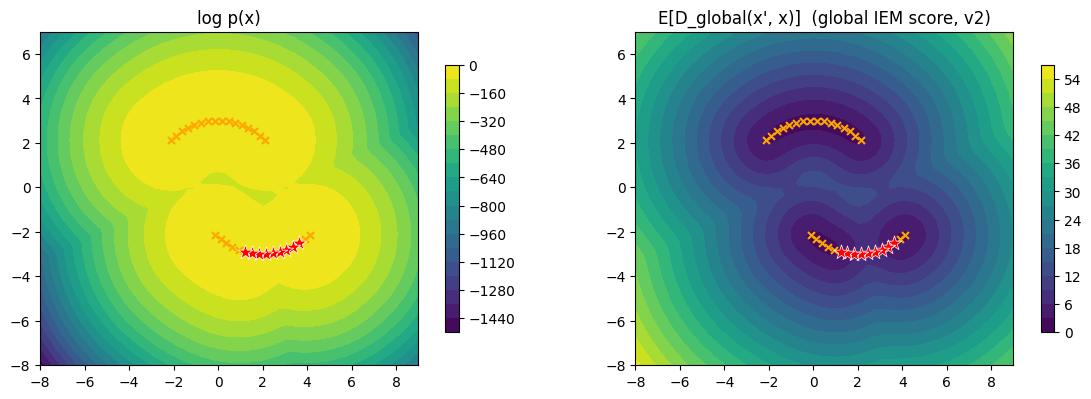

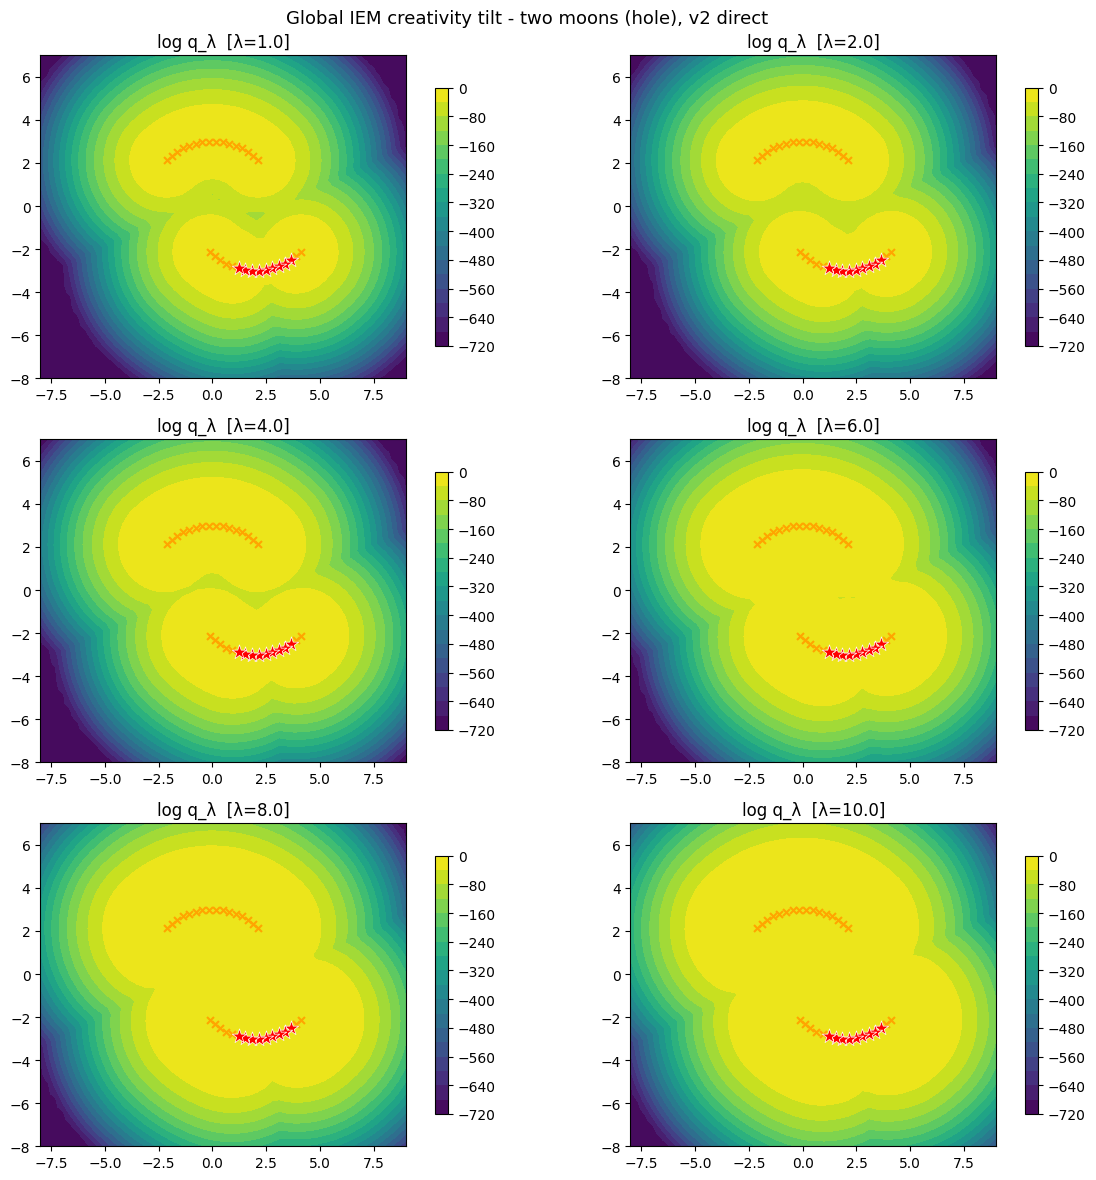

In [38]:
# plot log p and global IEM score (v2 direct)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_field(log_p_grid_moons2, XX, YY, ax=axes[0], title="log p(x)",
           marked=MEANS, missing=MISSING)
plot_field(expected_dist_global_moons2_v2, XX, YY, ax=axes[1],
           title="E[D_global(x', x)]  (global IEM score, v2)",
           marked=MEANS, missing=MISSING)
plt.tight_layout(); plt.show()

# Plot global IEM creativity measure for different λ values (v2)
lambdas = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0]

ncols = 2
nrows = math.ceil(len(lambdas) / ncols)
PANEL_W, PANEL_H = 6, 4

fig, axes = plt.subplots(nrows, ncols, figsize=(PANEL_W * ncols, PANEL_H * nrows))
axes = axes.flatten()
for i, LAMBDA in enumerate(lambdas):
    log_q_unnorm = log_p_grid_moons2 + LAMBDA * expected_dist_global_moons2_v2
    log_q, q, Z = grid_normalize(log_q_unnorm, cell_area)
    plot_field(log_q, XX, YY, ax=axes[i], title=f"log q_λ  [λ={LAMBDA}]",
               marked=MEANS, missing=MISSING)
for j in range(len(lambdas), len(axes)):
    axes[j].axis('off')
fig.suptitle("Global IEM creativity tilt - two moons (hole), v2 direct", fontsize=13)
plt.tight_layout(); plt.show()

## Swiss Roll

In [3]:
from sklearn.datasets import make_swiss_roll
from sklearn.mixture import GaussianMixture

N_SAMPLES = 5000        # samples for fitting
N_COMPONENTS = 24       # GMM beads along the spiral
D = 2

# Generate and project to 2D (x-z plane, drop height)
X_np, t_np = make_swiss_roll(n_samples=N_SAMPLES, noise=0.0, random_state=42)
X2d_np = X_np[:, [0, 2]]

# Fit spherical GMM (per-component isotropic variance, like existing experiments)
gmm = GaussianMixture(n_components=N_COMPONENTS, covariance_type='spherical',
                      random_state=42).fit(X2d_np)

MEANS        = torch.tensor(gmm.means_,       dtype=dtype)   # (K, 2)
VARS         = torch.tensor(gmm.covariances_, dtype=dtype)   # (K,)  per-component variance
LOG_WEIGHTS  = torch.log(torch.tensor(gmm.weights_, dtype=dtype))  # (K,)
K = MEANS.shape[0]

def log_pX(x):
    diff    = x.unsqueeze(-2) - MEANS                          # (..., K, 2)
    quad    = diff.pow(2).sum(-1) / VARS                       # (..., K)
    logcomp = -0.5 * quad - 0.5 * D * torch.log(2 * math.pi * VARS) + LOG_WEIGHTS
    return torch.logsumexp(logcomp, dim=-1)

def log_pY(y, gamma):
    gamma   = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var     = gamma**2 * VARS + gamma                          # (K,)
    diff    = y.unsqueeze(-2) - gamma * MEANS                  # (..., K, 2)
    quad    = diff.pow(2).sum(-1) / var
    logcomp = -0.5 * quad - 0.5 * D * torch.log(2 * math.pi * var) + LOG_WEIGHTS
    return torch.logsumexp(logcomp, dim=-1)

def roll_sample(n):
    idx = torch.multinomial(torch.exp(LOG_WEIGHTS), n, replacement=True)
    return MEANS[idx] + torch.sqrt(VARS[idx]).unsqueeze(-1) * torch.randn(n, 2, dtype=dtype)

p_roll = Density(log_pX, log_pY, sample_fn=roll_sample, d=2)
print(f"Swiss Roll GMM: {K} components, fitted to {N_SAMPLES} 2D samples")

grid_points_roll, XX, YY, cell_area = make_grid((-15, 15), (-15, 15), grid_n=50, dtype=dtype)
log_p_grid_roll = p_roll.log_p_X(grid_points_roll)
x_refs = p_roll.sample(32, seed=123)
print(f"Grid: {grid_points_roll.shape[0]} points, cell_area={cell_area:.4f}; refs: {x_refs.shape}")

Swiss Roll GMM: 24 components, fitted to 5000 2D samples
Grid: 2500 points, cell_area=0.3748; refs: torch.Size([32, 2])


### Swiss Roll - Local IEM

In [4]:
GAMMAS_LOCAL = torch.logspace(-4, 4, 128, base=2, dtype=dtype)
D_local_roll = LocalIEMDistance(p_roll, GAMMAS_LOCAL, num_noises=50)
expected_dist_roll = expected_distance(D_local_roll, grid_points_roll, x_refs)

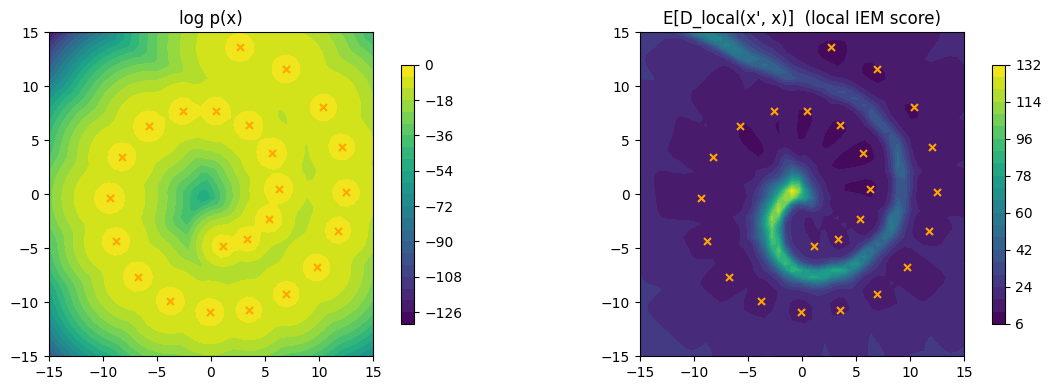

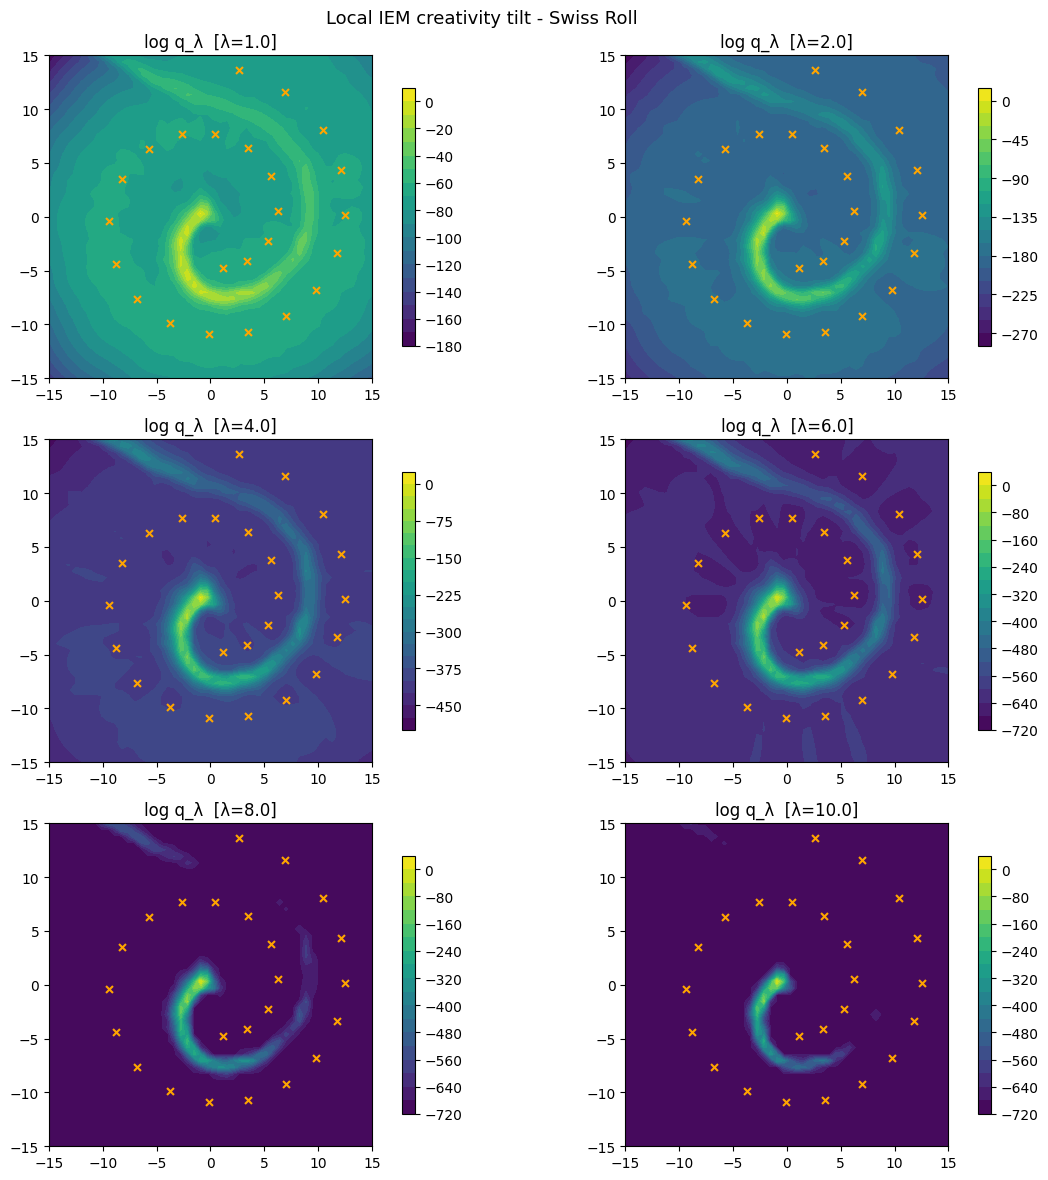

In [4]:
# plot log p and local IEM score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_field(log_p_grid_roll, XX, YY, ax=axes[0], title="log p(x)", marked=MEANS)
plot_field(expected_dist_roll, XX, YY, ax=axes[1],
           title="E[D_local(x', x)]  (local IEM score)", marked=MEANS)
plt.tight_layout(); plt.show()

lambdas = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0]
ncols = 2
nrows = math.ceil(len(lambdas) / ncols)
PANEL_W, PANEL_H = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(PANEL_W * ncols, PANEL_H * nrows))
axes = axes.flatten()
for i, LAMBDA in enumerate(lambdas):
    log_q_unnorm = log_p_grid_roll + LAMBDA * expected_dist_roll
    log_q, q, Z = grid_normalize(log_q_unnorm, cell_area)
    plot_field(log_q, XX, YY, ax=axes[i], title=f"log q_λ  [λ={LAMBDA}]", marked=MEANS)
for j in range(len(lambdas), len(axes)):
    axes[j].axis('off')
fig.suptitle("Local IEM creativity tilt - Swiss Roll", fontsize=13)
plt.tight_layout(); plt.show()

### Swiss Roll - Global IEM

In [5]:
GAMMAS_GLOBAL = torch.logspace(-10, 10, 200, base=2, dtype=dtype)
D_global_roll = GlobalIEMDistance(p_roll, GAMMAS_GLOBAL, num_eps=16)
expected_dist_global_roll = expected_distance(D_global_roll, grid_points_roll, x_refs)

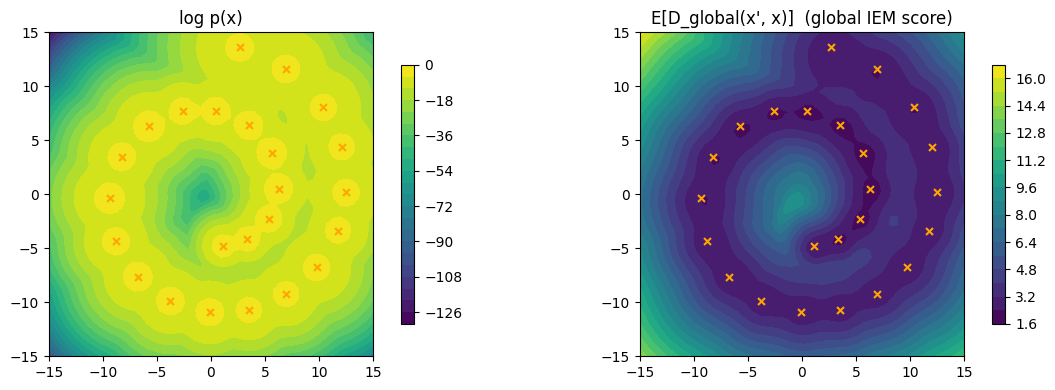

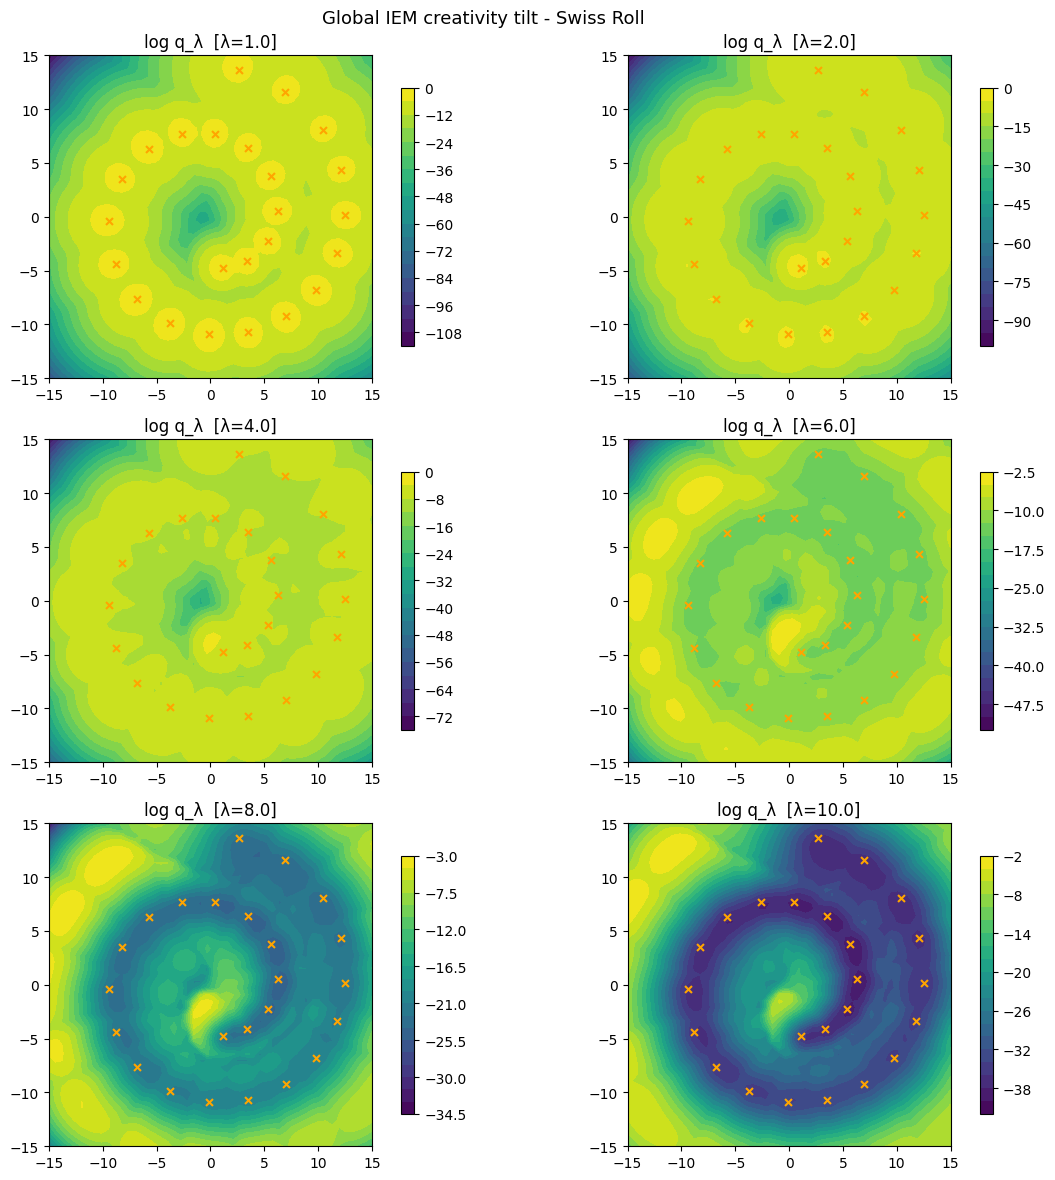

In [6]:
# plot log p and global IEM score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_field(log_p_grid_roll, XX, YY, ax=axes[0], title="log p(x)", marked=MEANS)
plot_field(expected_dist_global_roll, XX, YY, ax=axes[1],
           title="E[D_global(x', x)]  (global IEM score)", marked=MEANS)
plt.tight_layout(); plt.show()

lambdas = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0]
ncols = 2
nrows = math.ceil(len(lambdas) / ncols)
PANEL_W, PANEL_H = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(PANEL_W * ncols, PANEL_H * nrows))
axes = axes.flatten()
for i, LAMBDA in enumerate(lambdas):
    log_q_unnorm = log_p_grid_roll + LAMBDA * expected_dist_global_roll
    log_q, q, Z = grid_normalize(log_q_unnorm, cell_area)
    plot_field(log_q, XX, YY, ax=axes[i], title=f"log q_λ  [λ={LAMBDA}]", marked=MEANS)
for j in range(len(lambdas), len(axes)):
    axes[j].axis('off')
fig.suptitle("Global IEM creativity tilt - Swiss Roll", fontsize=13)
plt.tight_layout(); plt.show()

## Swiss Roll with a hole

In [6]:
N_SAMPLES_HOLE = 5000
N_COMPONENTS_HOLE = 24
T_HOLE_MIN, T_HOLE_MAX = 8.5, 9.5    # gap in the middle wrap (t ∈ [1.5π, 4.5π] ≈ [4.7, 14.1])

X_np2, t_np2 = make_swiss_roll(n_samples=N_SAMPLES_HOLE, noise=0.0, random_state=42)
X2d_np2 = X_np2[:, [0, 2]]

keep = ~((t_np2 >= T_HOLE_MIN) & (t_np2 <= T_HOLE_MAX))
X_kept = X2d_np2[keep]
X_hole = X2d_np2[~keep]

gmm2 = GaussianMixture(n_components=N_COMPONENTS_HOLE, covariance_type='spherical',
                       random_state=42).fit(X_kept)

MEANS        = torch.tensor(gmm2.means_,       dtype=dtype)
VARS         = torch.tensor(gmm2.covariances_, dtype=dtype)
LOG_WEIGHTS  = torch.log(torch.tensor(gmm2.weights_, dtype=dtype))
K = MEANS.shape[0]

# Downsample hole points for visualization (MISSING markers)
rng_vis = torch.Generator().manual_seed(0)
vis_idx = torch.randperm(len(X_hole), generator=rng_vis)[:50]
MISSING = torch.tensor(X_hole[vis_idx], dtype=dtype)

def log_pX(x):
    diff    = x.unsqueeze(-2) - MEANS
    quad    = diff.pow(2).sum(-1) / VARS
    logcomp = -0.5 * quad - 0.5 * D * torch.log(2 * math.pi * VARS) + LOG_WEIGHTS
    return torch.logsumexp(logcomp, dim=-1)

def log_pY(y, gamma):
    gamma   = torch.as_tensor(gamma, dtype=y.dtype, device=y.device)
    var     = gamma**2 * VARS + gamma
    diff    = y.unsqueeze(-2) - gamma * MEANS
    quad    = diff.pow(2).sum(-1) / var
    logcomp = -0.5 * quad - 0.5 * D * torch.log(2 * math.pi * var) + LOG_WEIGHTS
    return torch.logsumexp(logcomp, dim=-1)

def roll_hole_sample(n):
    idx = torch.multinomial(torch.exp(LOG_WEIGHTS), n, replacement=True)
    return MEANS[idx] + torch.sqrt(VARS[idx]).unsqueeze(-1) * torch.randn(n, 2, dtype=dtype)

p_roll2 = Density(log_pX, log_pY, sample_fn=roll_hole_sample, d=2)
print(f"Swiss Roll with hole: {K} components, hole t∈[{T_HOLE_MIN}, {T_HOLE_MAX}]")

grid_points_roll2, XX, YY, cell_area = make_grid((-15, 15), (-15, 15), grid_n=50, dtype=dtype)
log_p_grid_roll2 = p_roll2.log_p_X(grid_points_roll2)
x_refs = p_roll2.sample(32, seed=123)
print(f"Grid: {grid_points_roll2.shape[0]} points, cell_area={cell_area:.4f}; refs: {x_refs.shape}")

Swiss Roll with hole: 24 components, hole t∈[8.5, 9.5]
Grid: 2500 points, cell_area=0.3748; refs: torch.Size([32, 2])


### Swiss Roll with a hole - Local IEM

In [9]:
GAMMAS_LOCAL = torch.logspace(-4, 4, 128, base=2, dtype=dtype)
D_local_roll2 = LocalIEMDistance(p_roll2, GAMMAS_LOCAL, num_noises=50)
expected_dist_roll2 = expected_distance(D_local_roll2, grid_points_roll2, x_refs)

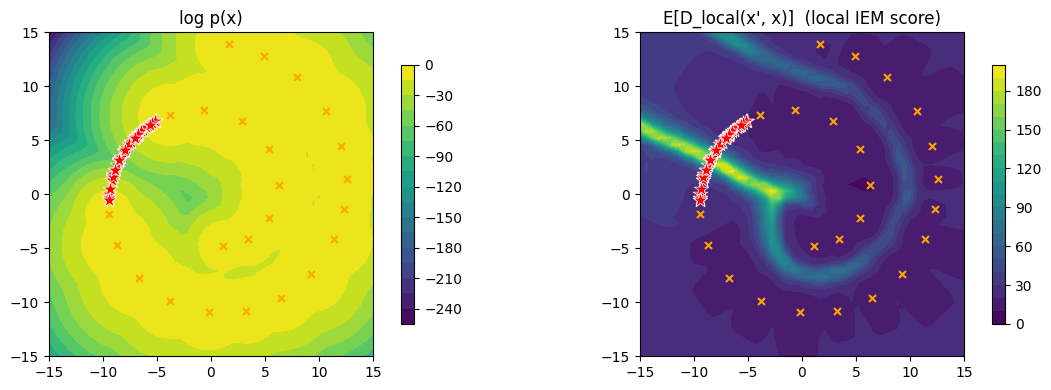

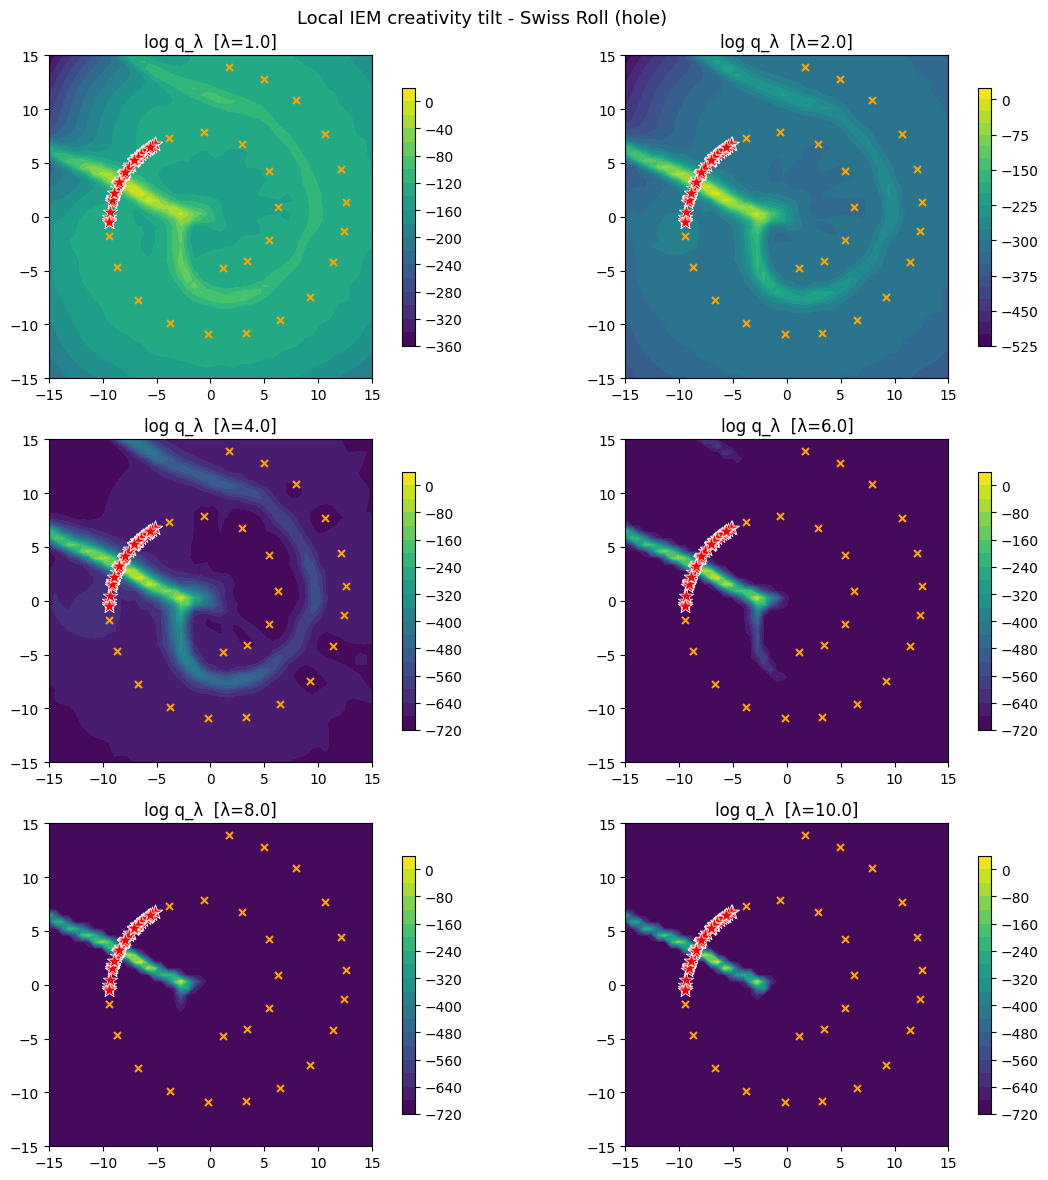

In [5]:
# plot log p and local IEM score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_field(log_p_grid_roll2, XX, YY, ax=axes[0], title="log p(x)", marked=MEANS, missing=MISSING)
plot_field(expected_dist_roll2, XX, YY, ax=axes[1],
           title="E[D_local(x', x)]  (local IEM score)", marked=MEANS, missing=MISSING)
plt.tight_layout(); plt.show()

lambdas = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0]
ncols = 2
nrows = math.ceil(len(lambdas) / ncols)
PANEL_W, PANEL_H = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(PANEL_W * ncols, PANEL_H * nrows))
axes = axes.flatten()
for i, LAMBDA in enumerate(lambdas):
    log_q_unnorm = log_p_grid_roll2 + LAMBDA * expected_dist_roll2
    log_q, q, Z = grid_normalize(log_q_unnorm, cell_area)
    plot_field(log_q, XX, YY, ax=axes[i], title=f"log q_λ  [λ={LAMBDA}]",
               marked=MEANS, missing=MISSING)
for j in range(len(lambdas), len(axes)):
    axes[j].axis('off')
fig.suptitle("Local IEM creativity tilt - Swiss Roll (hole)", fontsize=13)
plt.tight_layout(); plt.show()

### Swiss Roll with a hole - Lp distance baselines

In [10]:
# Baseline Minkowski-distance creativity scores: E_{x'~p}[ ||x - x'||_p ].
# L∞ replaces the degenerate L0 (p=0 is ~constant in continuous space → no tilt).
baseline_dists = [
    ("L∞", float("inf")),
    ("L1", 1.0),
    ("L2", 2.0),
]
expected_dist_lp = {
    name: expected_distance(LpDistance(p), grid_points_roll2, x_refs)
    for name, p in baseline_dists
}

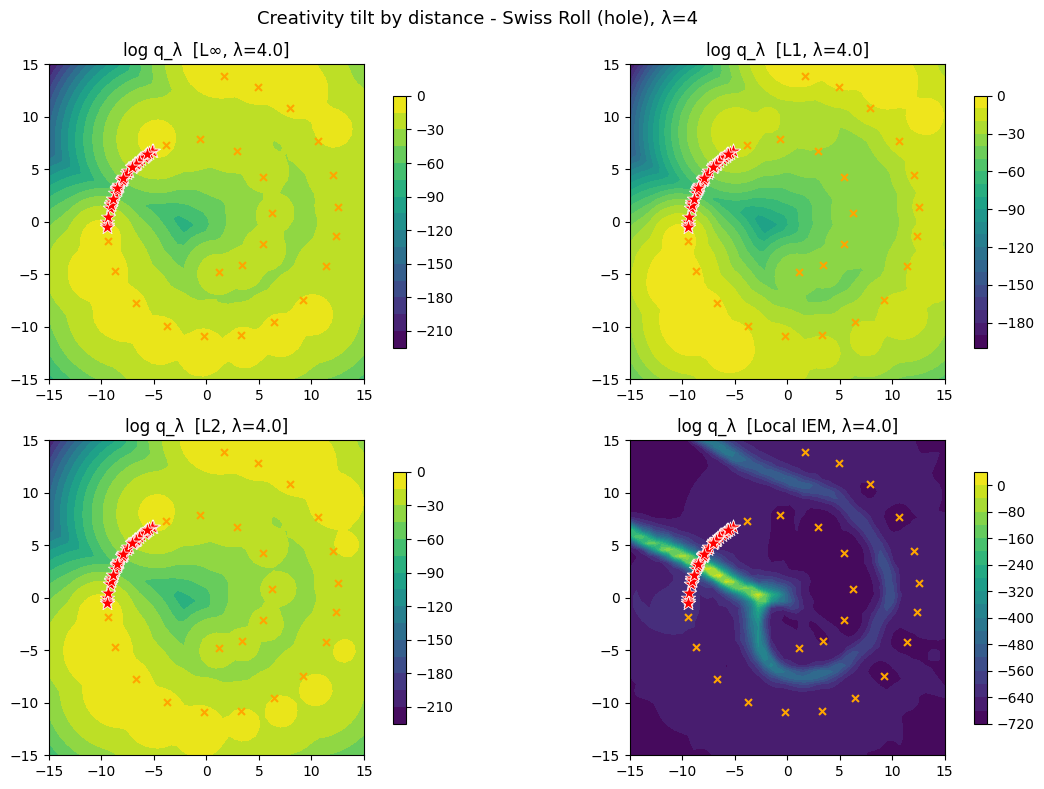

In [11]:
LAMBDA = 4.0
panels = [
    ("L∞",        expected_dist_lp["L∞"]),
    ("L1",        expected_dist_lp["L1"]),
    ("L2",        expected_dist_lp["L2"]),
    ("Local IEM", expected_dist_roll2),
]
ncols = 2
nrows = math.ceil(len(panels) / ncols)
PANEL_W, PANEL_H = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(PANEL_W * ncols, PANEL_H * nrows))
axes = axes.flatten()
for i, (name, edist) in enumerate(panels):
    log_q_unnorm = log_p_grid_roll2 + LAMBDA * edist
    log_q, q, Z = grid_normalize(log_q_unnorm, cell_area)
    plot_field(log_q, XX, YY, ax=axes[i], title=f"log q_λ  [{name}, λ={LAMBDA}]",
               marked=MEANS, missing=MISSING)
for j in range(len(panels), len(axes)):
    axes[j].axis('off')
fig.suptitle("Creativity tilt by distance - Swiss Roll (hole), λ=4", fontsize=13)
plt.tight_layout(); plt.show()

### Swiss Roll with a hole - Global IEM

In [6]:
GAMMAS_GLOBAL = torch.logspace(-10, 10, 200, base=2, dtype=dtype)
D_global_roll2 = GlobalIEMDistance(p_roll2, GAMMAS_GLOBAL, num_eps=16)
expected_dist_global_roll2 = expected_distance(D_global_roll2, grid_points_roll2, x_refs)

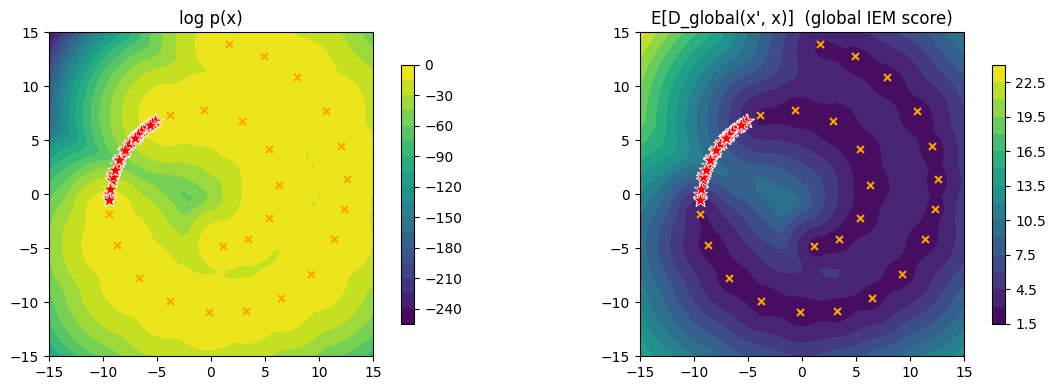

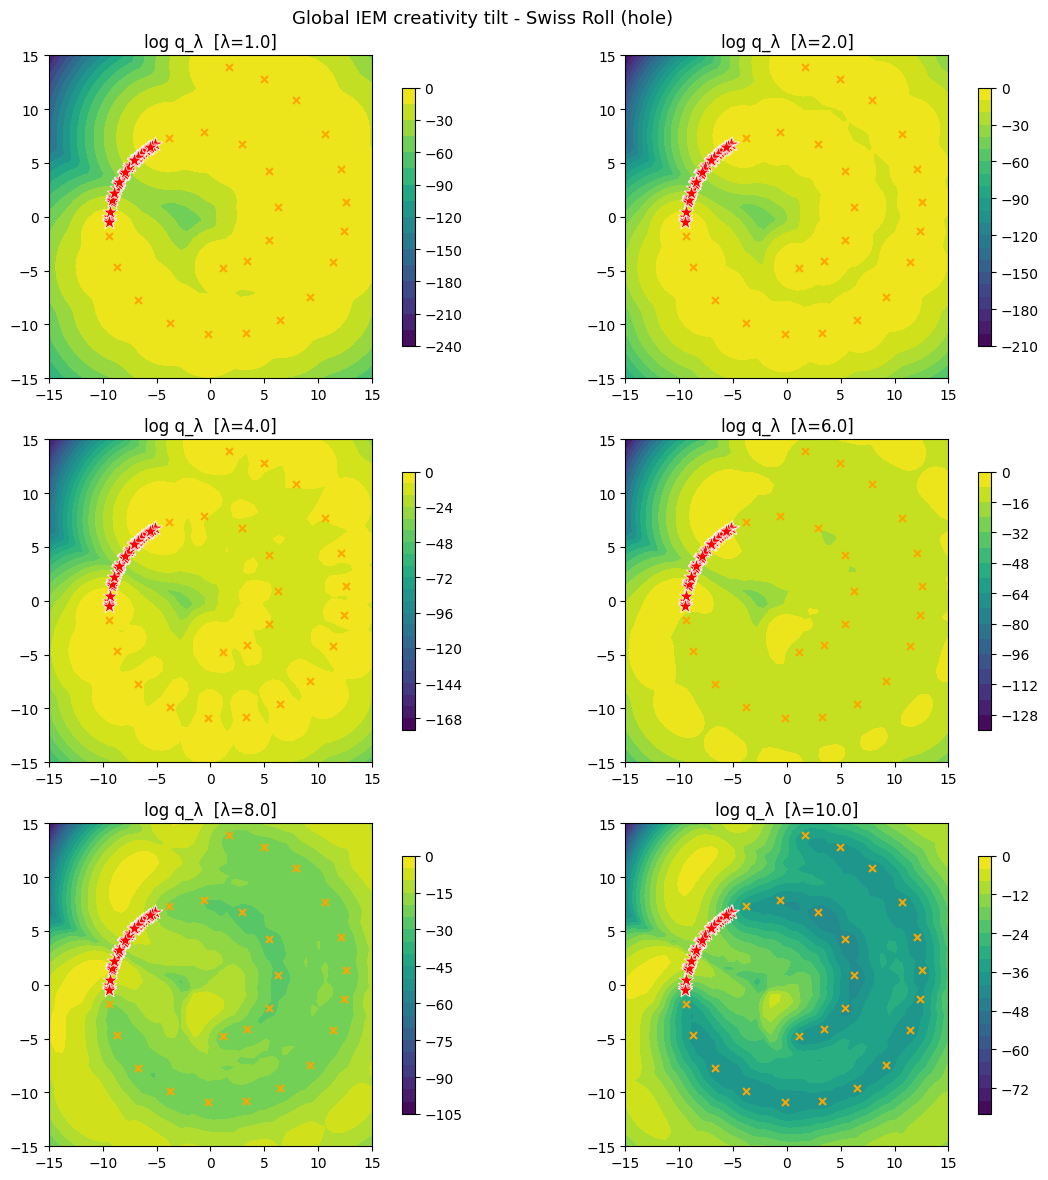

In [7]:
# plot log p and global IEM score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_field(log_p_grid_roll2, XX, YY, ax=axes[0], title="log p(x)", marked=MEANS, missing=MISSING)
plot_field(expected_dist_global_roll2, XX, YY, ax=axes[1],
           title="E[D_global(x', x)]  (global IEM score)", marked=MEANS, missing=MISSING)
plt.tight_layout(); plt.show()

lambdas = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0]
ncols = 2
nrows = math.ceil(len(lambdas) / ncols)
PANEL_W, PANEL_H = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(PANEL_W * ncols, PANEL_H * nrows))
axes = axes.flatten()
for i, LAMBDA in enumerate(lambdas):
    log_q_unnorm = log_p_grid_roll2 + LAMBDA * expected_dist_global_roll2
    log_q, q, Z = grid_normalize(log_q_unnorm, cell_area)
    plot_field(log_q, XX, YY, ax=axes[i], title=f"log q_λ  [λ={LAMBDA}]",
               marked=MEANS, missing=MISSING)
for j in range(len(lambdas), len(axes)):
    axes[j].axis('off')
fig.suptitle("Global IEM creativity tilt - Swiss Roll (hole)", fontsize=13)
plt.tight_layout(); plt.show()